# Actividad 3. Cuarteto de Anscombe con Python

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install numpy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('anscombe_capitulo1.csv')
df.head()

,conjunto,x,y
0,I,10,8.04
1,I,8,6.95
2,I,13,7.58
3,I,9,8.81
4,I,11,8.33


## Resumen estadístico por conjunto

In [6]:
resumen = df.groupby('conjunto').agg({'x': ['mean', 'var'], 'y': ['mean', 'var']})
resumen[('xy', 'corr')] = df.groupby('conjunto')[['x', 'y']].apply(lambda g: g['x'].corr(g['y']))
resumen.round(3)

x            y            xy
         mean   var   mean    var   corr
conjunto                                
I         9.0  11.0  7.501  4.127  0.816
II        9.0  11.0  7.501  4.128  0.816
III       9.0  11.0  7.500  4.123  0.816
IV        9.0  11.0  7.501  4.123  0.817

## Gráficos de dispersión con línea de regresión

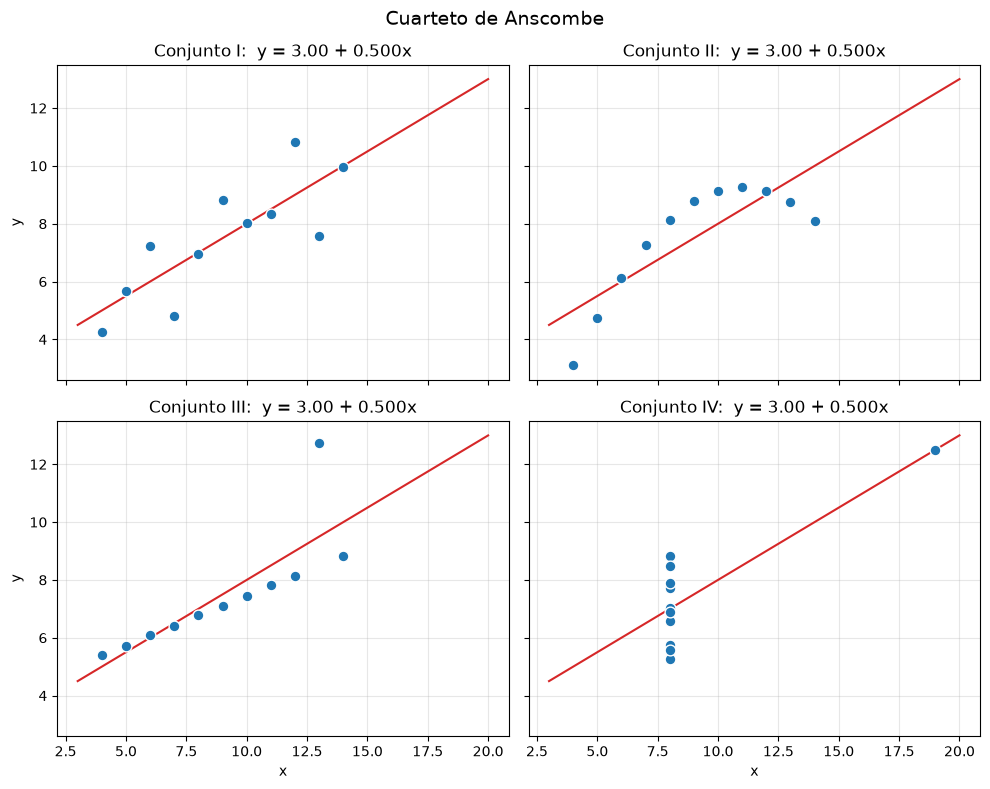

In [7]:
conjuntos = ['I', 'II', 'III', 'IV']
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
x_linea = np.linspace(df['x'].min() - 1, df['x'].max() + 1, 100)

for ax, conjunto in zip(axes.flat, conjuntos):
    datos = df[df['conjunto'] == conjunto]
    pendiente, ordenada = np.polyfit(datos['x'], datos['y'], 1)

    ax.scatter(datos['x'], datos['y'], color='tab:blue', edgecolor='white', s=60, zorder=3)
    ax.plot(x_linea, pendiente * x_linea + ordenada, color='tab:red', linewidth=1.5)
    ax.set_title(f'Conjunto {conjunto}:  y = {ordenada:.2f} + {pendiente:.3f}x')
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel('x')
for ax in axes[:, 0]:
    ax.set_ylabel('y')

fig.suptitle('Cuarteto de Anscombe', fontsize=14)
fig.tight_layout()
plt.show()

## Conclusión

Los cuatro conjuntos comparten prácticamente el mismo resumen estadístico: media de x = 9, varianza de x = 11, media de y ≈ 7.50, varianza de y ≈ 4.12, correlación ≈ 0.816 y la misma recta de regresión (y ≈ 3.00 + 0.500x). Si solo se miraran esas cifras, se concluiría que los cuatro conjuntos son equivalentes. Los gráficos muestran lo contrario: el conjunto I sí sigue una relación lineal con ruido; el II es una curva (relación cuadrática) que la recta no captura; el III es una línea casi perfecta desviada por un único valor atípico; y en el IV la x es constante salvo un punto extremo, que por sí solo genera toda la correlación.

Esto ilustra la idea de Munzner: un resumen estadístico comprime los datos en unos pocos números y, al hacerlo, esconde su verdadera estructura (forma de la relación, valores atípicos, puntos de alta influencia). La visualización no reemplaza a la estadística, pero es necesaria para ver patrones que los resúmenes no pueden mostrar y para detectar cuándo un modelo, como la regresión lineal, no es adecuado.

# Actividad 4. Prototipo de tablero interactivo simple

In [8]:
import seaborn as sns
from ipywidgets import interact

notas = pd.read_csv('bases_datos2_labs_capitulo1.csv')
notas.head()

,ID_Estudiante,Grupo,Laboratorio,Nota
0,GS123-01,GS123,Lab1,85.8
1,GS123-01,GS123,Lab2,93.5
2,GS123-01,GS123,Lab3,95.7
3,GS123-01,GS123,Lab4,78.1
4,GS123-01,GS123,Lab5,89.8


## Vista estática: todos los estudiantes y laboratorios

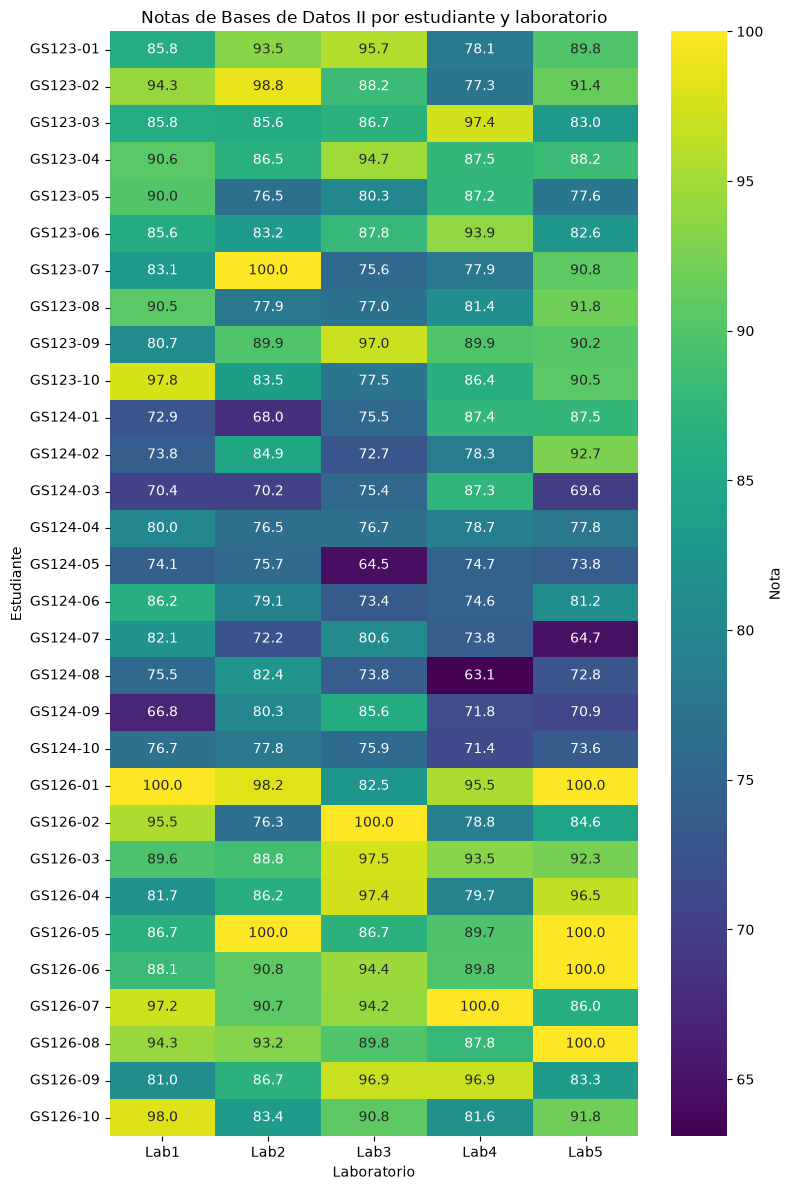

In [9]:
matriz = pd.pivot_table(notas, index='ID_Estudiante', columns='Laboratorio', values='Nota')

plt.figure(figsize=(8, 12))
sns.heatmap(matriz, annot=True, fmt='.1f', cmap='viridis', cbar_kws={'label': 'Nota'})
plt.title('Notas de Bases de Datos II por estudiante y laboratorio')
plt.xlabel('Laboratorio')
plt.ylabel('Estudiante')
plt.tight_layout()
plt.show()

## Vista interactiva: filtro por laboratorio y por grupo

In [ ]:
opciones_lab = ['Todos'] + sorted(notas['Laboratorio'].unique())
opciones_grupo = ['Todos'] + sorted(notas['Grupo'].unique())

def mostrar_notas(laboratorio='Todos', grupo='Todos'):
    datos = notas
    if laboratorio != 'Todos':
        datos = datos[datos['Laboratorio'] == laboratorio]
    if grupo != 'Todos':
        datos = datos[datos['Grupo'] == grupo]

    matriz_filtrada = pd.pivot_table(datos, index='ID_Estudiante', columns='Laboratorio', values='Nota')
    # Con un solo laboratorio, ordenar de mayor a menor nota facilita comparar estudiantes
    if laboratorio != 'Todos':
        matriz_filtrada = matriz_filtrada.sort_values(laboratorio, ascending=False)

    alto = max(3, 0.4 * len(matriz_filtrada))
    plt.figure(figsize=(8, alto))
    # vmin/vmax fijos para que los colores sean comparables entre filtros
    sns.heatmap(matriz_filtrada, annot=True, fmt='.1f', cmap='viridis',
                vmin=notas['Nota'].min(), vmax=notas['Nota'].max(), cbar_kws={'label': 'Nota'})
    plt.title(f'Laboratorio: {laboratorio} | Grupo: {grupo} | Promedio: {datos["Nota"].mean():.1f}')
    plt.xlabel('Laboratorio')
    plt.ylabel('Estudiante')
    plt.tight_layout()
    plt.show()

interact(mostrar_notas, laboratorio=opciones_lab, grupo=opciones_grupo);

## Comparación: vista estática vs. interactiva

El mapa de calor estático muestra las 150 notas a la vez: sirve para una visión general (por ejemplo, detectar a simple vista celdas muy bajas), pero obliga al lector a buscar dentro de una matriz grande cada vez que tiene una pregunta concreta. La versión interactiva permite responder distintas preguntas sobre el mismo conjunto de datos sin crear un gráfico nuevo para cada una: al elegir un laboratorio, la vista se reduce a una columna ordenada de mayor a menor, lo que responde de inmediato "¿quién tuvo el mejor y el peor resultado en el Lab3?"; al elegir un grupo, se aíslan sus 10 estudiantes y su promedio, lo que permite comparar grupos entre sí; y combinando ambos filtros se puede analizar un laboratorio dentro de un grupo específico. Como la escala de color se mantiene fija, las vistas filtradas siguen siendo comparables entre sí. En resumen, la interactividad traslada al usuario la decisión de qué parte de los datos mirar, reduce la carga visual y adapta una misma fuente de datos a múltiples tareas de análisis.